## 2. Handling Ordinality

### Does encoding ordinality via Regressor-based Ensembles outperform standard Multiclass Classifiers in Air Quality Assessment?

Our target variable — `Good`, `Moderate`, `Poor`, `Hazardous` — is not a nominal class. It carries an inherent order:

$$\text{Good} < \text{Moderate} < \text{Poor} < \text{Hazardous}$$

Standard multiclass classification ignores this structure entirely, treating a prediction of `Good` when the true label is `Hazardous` as an error equivalent in severity to predicting `Moderate`. In a real-world air quality context, these are fundamentally different mistakes.

| Approach | Description |
|---|---|
| **Standard Multiclass** | Treats the 4 classes as independent nominal labels. No ordering assumed. |
| **Frank & Hall** | Decomposes the problem into 3 binary classifiers: `P(y > Good)`, `P(y > Moderate)`, `P(y > Poor)`. Outputs are combined to recover the 4-class distribution while preserving ordinal structure. |
| **Regressor Ensemble** | Trains an XGBoost Regressor on the numeric labels `{0,1,2,3}`, then maps the continuous output back to the nearest class via tuned thresholds. |

All three models are fine-tuned with **Optuna + MedianPruner**. Evaluation uses both standard metrics (Accuracy, F1, MCC) and **ordinal-aware metrics** that penalise predictions proportionally to how far off they are.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, f1_score,
    matthews_corrcoef, cohen_kappa_score, mean_absolute_error
)
from scipy.stats import kendalltau, spearmanr
from xgboost import XGBClassifier, XGBRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

PALETTE   = {3: "#2ecc71", 2: "#f39c12", 1: "#e74c3c", 0: "#8e44ad"}
LABEL_MAP = {3: "Good", 2: "Moderate", 1: "Poor", 0: "Hazardous"}
CLASS_LABELS = ["Hazardous", "Poor", "Moderate", "Good"]
RANDOM_STATE = 42

In [ ]:
data = pd.read_csv("../data/updated_pollution_dataset.csv")
target_col  = data.columns[-1]
quality_map = {"Good": 3, "Moderate": 2, "Poor": 1, "Hazardous": 0}
data[target_col] = data[target_col].map(quality_map).astype("int8")

feature_cols = [col for col in data.columns if col != target_col]
X = data[feature_cols].values
y = data[target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Class distribution (train): { {LABEL_MAP[k]: v for k, v in zip(*np.unique(y_train, return_counts=True))} }")

Train: (4000, 9)  |  Test: (1000, 9)
Class distribution (train): {'Hazardous': np.int64(400), 'Poor': np.int64(800), 'Moderate': np.int64(1200), 'Good': np.int64(1600)}


In [ ]:
def evaluate(y_true, y_pred, model_name):
    """
    Returns a metrics dictionary covering both standard and ordinal-aware metrics.

    Standard  : Accuracy, Macro F1, MCC
    Ordinal   : MAE (class steps), Adjacent Accuracy, Quadratic Weighted Kappa, Linear Weighted Kappa,
                Kendall's Tau, Spearman's Rho, Severe Error Rate (>=2 steps),
                Adjacent Error Rate
    """
    err          = np.abs(y_true - y_pred)
    tau, _       = kendalltau(y_true, y_pred)
    rho, _       = spearmanr(y_true, y_pred)

    return {
        "Model":                    model_name,
            #  Standard metrics
        "Accuracy":                 round(accuracy_score(y_true, y_pred), 4),
        "Macro F1":                 round(f1_score(y_true, y_pred, average="macro"), 4),
        "MCC":                      round(matthews_corrcoef(y_true, y_pred), 4),
            #  Ordinal metrics
        "MAE (class steps)":        round(mean_absolute_error(y_true, y_pred), 4),
        "Adjacent Accuracy":        round((err <= 1).mean(), 4),
        "Quadratic Weighted κ":     round(cohen_kappa_score(y_true, y_pred, weights="quadratic"), 4),
        "Linear Weighted κ":        round(cohen_kappa_score(y_true, y_pred, weights="linear"), 4),
        "Kendall's τ":              round(tau, 4),
        "Spearman's ρ":             round(rho, 4),
        "Severe Error Rate (≥2)":   round((err >= 2).mean(), 4),
        "Adjacent Error Rate":      round((err == 1).mean(), 4),
    }

In [ ]:
#  Optuna objective function for XGBoost 
def objective_cat(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "use_label_encoder": False,
        "eval_metric":       "mlogloss",
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
    }
    cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    f1  = cross_val_score(
        XGBClassifier(**params), X_train, y_train,
        cv=cv, scoring="f1_macro", n_jobs=-1
    ).mean()

    # Report intermediate value for pruning
    trial.report(f1, step=0)
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()
    return f1

study_cat = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0),
)
study_cat.optimize(objective_cat, n_trials=40, show_progress_bar=True)

best_params_cat = study_cat.best_params
best_params_cat.update({"use_label_encoder": False, "eval_metric": "mlogloss",
                        "random_state": RANDOM_STATE, "n_jobs": -1})

print(f"Best CV Macro F1 (categorical): {study_cat.best_value:.4f}")
print(f"Best params: {best_params_cat}")

#  Train final model with best hyperparameters and evaluate on test set
cat_model = XGBClassifier(**best_params_cat)
cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test)

metrics_cat = evaluate(y_test, y_pred_cat, "Standard Multiclass (XGBoost)")
print("\nTest metrics:")
pd.DataFrame([metrics_cat]).set_index("Model").T

  0%|          | 0/40 [00:00<?, ?it/s]

Best CV Macro F1 (categorical): 0.9346
Best params: {'n_estimators': 515, 'max_depth': 6, 'learning_rate': 0.040755806200489235, 'subsample': 0.8123805027776834, 'colsample_bytree': 0.5496745600123494, 'min_child_weight': 2, 'use_label_encoder': False, 'eval_metric': 'mlogloss', 'random_state': 42, 'n_jobs': -1}

Test metrics:


Model,Standard Multiclass (XGBoost)
Accuracy,0.9440
Macro F1,0.9212
MCC,0.9200
MAE (class steps),0.0560
Adjacent Accuracy,1.0000
Quadratic Weighted κ,0.9711
Linear Weighted κ,0.9473
Kendall's τ,0.9669
Spearman's ρ,0.9820
Severe Error Rate (≥2),0.0000


In [ ]:
#  Optuna objective Frank & Hall
def objective_fh(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "use_label_encoder": False,
        "eval_metric":       "logloss",
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    # Train 3 binary classifiers and reconstruct 4-class probabilities per fold
    qwk_scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        p_gt = {}
        for t in [0, 1, 2]:
            clf = XGBClassifier(**params)
            clf.fit(X_tr, (y_tr > t).astype(int))
            p_gt[t] = clf.predict_proba(X_val)[:, 1]

        # Enforce monotonicity: P(y>0) >= P(y>1) >= P(y>2)
        p0 = p_gt[0]
        p1 = np.minimum(p_gt[1], p0)
        p2 = np.minimum(p_gt[2], p1)

        proba = np.column_stack([1 - p0, p0 - p1, p1 - p2, p2])
        proba = np.clip(proba, 0, None)
        proba /= proba.sum(axis=1, keepdims=True)
        y_pred_fold = np.argmax(proba, axis=1)

        qwk_scores.append(cohen_kappa_score(y_val, y_pred_fold, weights="quadratic"))

    qwk = np.mean(qwk_scores)
    trial.report(qwk, step=0)
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()
    return qwk

study_fh = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0),
)
study_fh.optimize(objective_fh, n_trials=40, show_progress_bar=True)

best_params_fh = study_fh.best_params
best_params_fh.update({"use_label_encoder": False, "eval_metric": "logloss",
                        "random_state": RANDOM_STATE, "n_jobs": -1})
print(f"Best CV QWK (Frank & Hall): {study_fh.best_value:.4f}")

#  Train final Frank & Hall model
bin_models = {}
for t in [0, 1, 2]:
    clf = XGBClassifier(**best_params_fh)
    clf.fit(X_train, (y_train > t).astype(int))
    bin_models[t] = clf
    print(f"  Binary classifier P(y > {t}) trained")

#  Reconstruct with monotonicity enforcement 
p_gt = {t: bin_models[t].predict_proba(X_test)[:, 1] for t in [0, 1, 2]}
p0 = p_gt[0]
p1 = np.minimum(p_gt[1], p0)
p2 = np.minimum(p_gt[2], p1)

proba_ord = np.column_stack([1 - p0, p0 - p1, p1 - p2, p2])
proba_ord = np.clip(proba_ord, 0, None)
proba_ord /= proba_ord.sum(axis=1, keepdims=True)
y_pred_fh = np.argmax(proba_ord, axis=1)

#  Monotonicity violation check 
raw_p_gt = {t: bin_models[t].predict_proba(X_test)[:, 1] for t in [0, 1, 2]}
violations = ((raw_p_gt[0] < raw_p_gt[1]) | (raw_p_gt[1] < raw_p_gt[2])).mean()
print(f"\nMonotonicity violation rate (before enforcement): {violations:.2%}")
if violations > 0.05:
    print("⚠  >5% violations — monotonicity assumption is not well satisfied on this data.")
else:
    print("✓  Monotonicity assumption largely holds.")

metrics_fh = evaluate(y_test, y_pred_fh, "Ordinal — Frank & Hall")
print("\nTest metrics:")
pd.DataFrame([metrics_fh]).set_index("Model").T

  0%|          | 0/40 [00:00<?, ?it/s]

Best CV QWK (Frank & Hall): 0.9795
  Binary classifier P(y > 0) trained
  Binary classifier P(y > 1) trained
  Binary classifier P(y > 2) trained

Monotonicity violation rate (before enforcement): 0.10%
✓  Monotonicity assumption largely holds.

Test metrics:


Model,Ordinal — Frank & Hall
Accuracy,0.9490
Macro F1,0.9263
MCC,0.9271
MAE (class steps),0.0510
Adjacent Accuracy,1.0000
Quadratic Weighted κ,0.9737
Linear Weighted κ,0.9520
Kendall's τ,0.9706
Spearman's ρ,0.9843
Severe Error Rate (≥2),0.0000


In [ ]:
def objective_reg(trial):
    #  Model hyperparameters 
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
    }
    #  Decision thresholds (t1 < t2 < t3) 
    # Map continuous output to: <t1=Hazardous, t1-t2=Poor, t2-t3=Moderate, >t3=Good
    t1 = trial.suggest_float("t1", 0.3, 1.2)
    t2 = trial.suggest_float("t2", 1.2, 2.2)
    t3 = trial.suggest_float("t3", 2.2, 3.0)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    qwk_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        reg = XGBRegressor(**params)
        reg.fit(X_tr, y_tr)
        preds_raw = reg.predict(X_val)
        preds     = np.digitize(preds_raw, bins=[t1, t2, t3])
        qwk_scores.append(cohen_kappa_score(y_val, preds, weights="quadratic"))

    qwk = np.mean(qwk_scores)
    trial.report(qwk, step=0)
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()
    return qwk

study_reg = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0),
)
study_reg.optimize(objective_reg, n_trials=50, show_progress_bar=True)

best = study_reg.best_params
print(f"Best CV QWK (Regressor): {study_reg.best_value:.4f}")
print(f"Optimal thresholds — t1={best['t1']:.3f}, t2={best['t2']:.3f}, t3={best['t3']:.3f}")

#  Train final regressor 
reg_params = {k: v for k, v in best.items() if k not in ["t1", "t2", "t3"]}
reg_params.update({"random_state": RANDOM_STATE, "n_jobs": -1})

reg_model   = XGBRegressor(**reg_params)
reg_model.fit(X_train, y_train)
preds_raw   = reg_model.predict(X_test)
y_pred_reg  = np.digitize(preds_raw, bins=[best["t1"], best["t2"], best["t3"]])

metrics_reg = evaluate(y_test, y_pred_reg, "Ordinal — Regressor Ensemble")
print("\nTest metrics:")
pd.DataFrame([metrics_reg]).set_index("Model").T

  0%|          | 0/50 [00:00<?, ?it/s]

Best CV QWK (Regressor): 0.9756
Optimal thresholds — t1=0.656, t2=1.467, t3=2.390

Test metrics:


Model,Ordinal — Regressor Ensemble
Accuracy,0.9450
Macro F1,0.9222
MCC,0.9215
MAE (class steps),0.0550
Adjacent Accuracy,1.0000
Quadratic Weighted κ,0.9724
Linear Weighted κ,0.9489
Kendall's τ,0.9678
Spearman's ρ,0.9827
Severe Error Rate (≥2),0.0000


In [ ]:
results_df = (
    pd.DataFrame([metrics_cat, metrics_fh, metrics_reg])
    .set_index("Model")
)

# Highlight best value per metric
def highlight_best(s):
    # For error metrics lower is better, for the rest higher is better
    lower_is_better = {"MAE (class steps)", "Severe Error Rate (≥2)", "Adjacent Error Rate"}
    if s.name in lower_is_better:
        best = s == s.min()
    else:
        best = s == s.max()
    return ["font-weight: bold; color: green" if v else "" for v in best]

print("Full Results — Standard + Ordinal Metrics")
results_df.T.style.apply(highlight_best, axis=1)

Full Results — Standard + Ordinal Metrics


Model,Standard Multiclass (XGBoost),Ordinal — Frank & Hall,Ordinal — Regressor Ensemble
Accuracy,0.944000,0.949000,0.945000
Macro F1,0.921200,0.926300,0.922200
MCC,0.920000,0.927100,0.921500
MAE (class steps),0.056000,0.051000,0.055000
Adjacent Accuracy,1.000000,1.000000,1.000000
Quadratic Weighted κ,0.971100,0.973700,0.972400
Linear Weighted κ,0.947300,0.952000,0.948900
Kendall's τ,0.966900,0.970600,0.967800
Spearman's ρ,0.982000,0.984300,0.982700
Severe Error Rate (≥2),0.000000,0.000000,0.000000


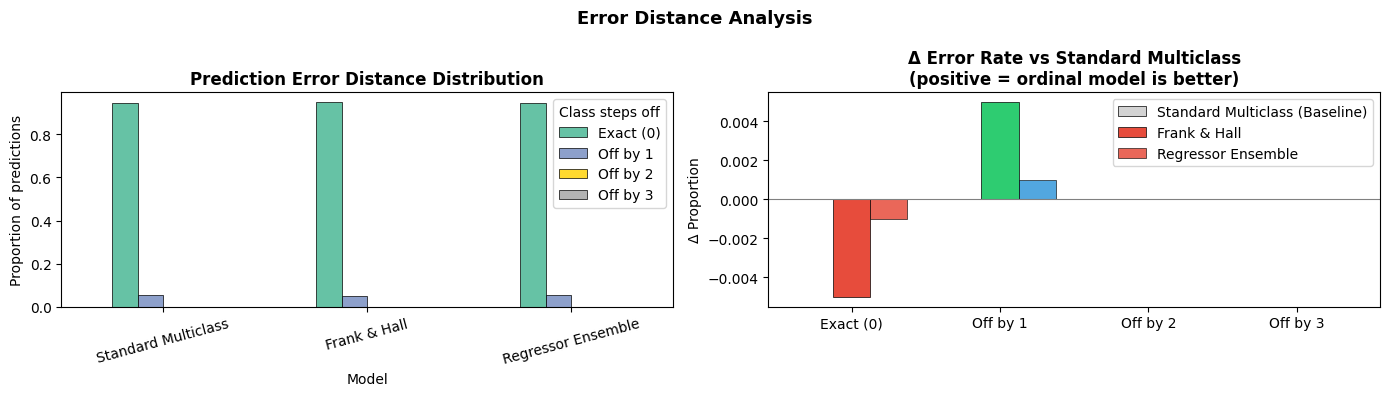

In [ ]:
err_cat = np.abs(y_test - y_pred_cat)
err_fh  = np.abs(y_test - y_pred_fh)
err_reg = np.abs(y_test - y_pred_reg)

err_df = pd.DataFrame({
    "Standard Multiclass": np.bincount(err_cat, minlength=4) / len(y_test),
    "Frank & Hall":        np.bincount(err_fh,  minlength=4) / len(y_test),
    "Regressor Ensemble":  np.bincount(err_reg, minlength=4) / len(y_test),
}, index=["Exact (0)", "Off by 1", "Off by 2", "Off by 3"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

err_df.T.plot(kind="bar", ax=axes[0], colormap="Set2",
            edgecolor="black", linewidth=0.5)
axes[0].set_title("Prediction Error Distance Distribution", fontweight="bold")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Proportion of predictions")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)
axes[0].legend(title="Class steps off")

# Delta vs Standard
delta_std = err_df["Standard Multiclass"] - err_df["Standard Multiclass"]
delta_fh  = err_df["Standard Multiclass"] - err_df["Frank & Hall"]
delta_reg = err_df["Standard Multiclass"] - err_df["Regressor Ensemble"]

x         = np.arange(len(err_df))
width     = 0.25

# 1. Standard Multiclass (Baseline)
axes[1].bar(x - width, delta_std, width, label="Standard Multiclass (Baseline)",
            color="lightgray", edgecolor="black", linewidth=0.5)

# 2. Frank & Hall
axes[1].bar(x, delta_fh, width, label="Frank & Hall",
            color=["#2ecc71" if v >= 0 else "#e74c3c" for v in delta_fh],
            edgecolor="black", linewidth=0.5)

# 3. Regressor Ensemble
axes[1].bar(x + width, delta_reg, width, label="Regressor Ensemble",
            color=["#3498db" if v >= 0 else "#e74c3c" for v in delta_reg],
            edgecolor="black", linewidth=0.5, alpha=0.85)

axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(err_df.index)
axes[1].set_title("Δ Error Rate vs Standard Multiclass\n(positive = ordinal model is better)",
                fontweight="bold")
axes[1].set_ylabel("Δ Proportion")
axes[1].legend()

plt.suptitle("Error Distance Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

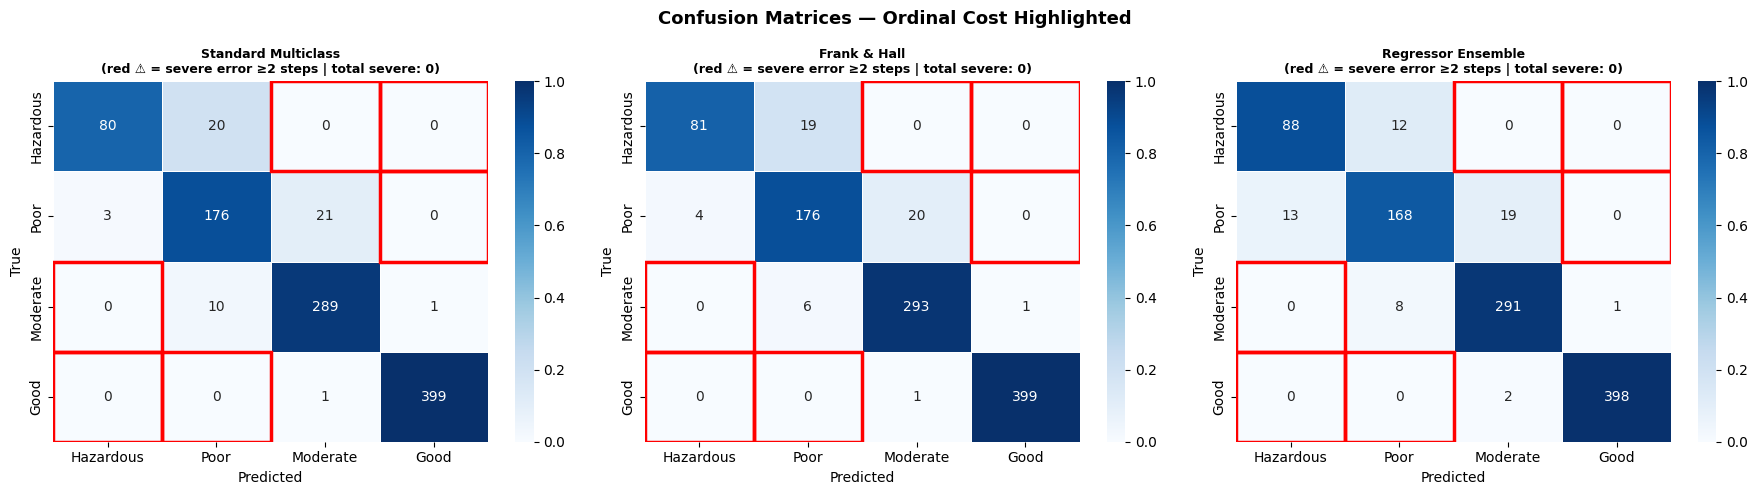

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (y_pred, title) in zip(axes, [
    (y_pred_cat, "Standard Multiclass"),
    (y_pred_fh,  "Frank & Hall"),
    (y_pred_reg, "Regressor Ensemble"),
]):
    cm      = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, ax=ax, annot=cm, fmt="d",
        cmap="Blues", linewidths=0.5,
        xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
        vmin=0, vmax=1,
    )

    for i in range(4):
        for j in range(4):
            dist = abs(i - j)
            if dist >= 2:
                ax.add_patch(plt.Rectangle(
                    (j, i), 1, 1,
                    fill=False, edgecolor="red", linewidth=2.5, zorder=3
                ))
                if cm[i, j] > 0:
                    ax.text(j + 0.5, i + 0.85, "⚠",
                            ha="center", fontsize=10, color="red", zorder=4)

    # Severe error count summary
    severe = sum(cm[i, j] for i in range(4) for j in range(4) if abs(i-j) >= 2)
    ax.set_title(
        f"{title}\n(red ⚠ = severe error ≥2 steps | total severe: {severe})",
        fontweight="bold", fontsize=9
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrices — Ordinal Cost Highlighted", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Results Summary

### What the metrics tell us

The comparison uses both standard metrics like Accuracy, F1, MCC and ordinal-aware metrics that measure the magnitude of errors, not just if a prediction is predicting the right or wrong value.

The key metrics to focus on are:
- **QWK**: the primary ordinal metric; higher means errors are concentrated near the diagonal
- **MAE**: lower is better; tells you on average how many steps away predictions land
- **Severe Error Rate**: the most safety-critical metric; a `Good` predicted as `Hazardous` is a worse prediction than a `Good` predicted as `Moderate`
- **Adjacent Accuracy**: a ordinal alternative to accuracy; a prediction that is off by one class still scores

### What the results show

All three models achieve extremely high overall accuracy (between 94% and 95%) with no severe errors on the clean dataset, which reflects a synthetic nature of the data, which tells us that class boundaries are well-separated in the original feature space.

The ordinal methods do not outperform the standard classifier on clean data by a lot, which is, more or less, what we expected. Because classes are easily separable, there is no ordinal structure to exploit.

### Frank & Hall
The monotonicity violation rate is just 0.10%, which means the binary classifiers are producing consistent probabilities almost every time. The ordinal decomposition assumption holds well on this data, so the enforcement step is rarely needed.

### Regressor Ensemble
The regressor takes a different approach, instead of decomposing the problem into binary decisions, it learns a continuous pollution score and uses Optuna-tuned thresholds to map it back to classes. This makes it more flexible and less dependent.

### Conclusion
On clean data the three models are essentially tied, but the **Frank & Hall** being a little bit better. The question is what would happen if the data gets harder, if we have more examples or if the values were more overlapped. Would ordinal methods hold up better under class overlap? That is what we have done in the next part of the notebook.

In [ ]:
data = pd.read_csv("../data/updated_pollution_dataset.csv")
target_col  = data.columns[-1]
quality_map = {"Good": 3, "Moderate": 2, "Poor": 1, "Hazardous": 0}
data[target_col] = data[target_col].map(quality_map).astype("int8")

feature_cols = [col for col in data.columns if col != target_col]
X = data[feature_cols].values
y = data[target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Class distribution (train): { {LABEL_MAP[k]: v for k, v in zip(*np.unique(y_train, return_counts=True))} }")

Train: (4000, 9)  |  Test: (1000, 9)
Class distribution (train): {'Hazardous': np.int64(400), 'Poor': np.int64(800), 'Moderate': np.int64(1200), 'Good': np.int64(1600)}


In [11]:
# Noise levels
# 0.0 → original clean data
# 1.0 → light overlap
# 1.5 → moderate overlap
# 3.0 → heavy overlap

# noise=0.0 already computed in Part 1
NOISE_LEVELS = [0.0, 1.0, 1.5, 3.0]
NOISE_LEVELS_TO_RUN = [1.0, 1.5, 3.0]

X_clean = X.copy()
y_clean = y.copy()

# Seed all_results with the Part 1 results at noise=0.0
metrics_cat_0 = {**metrics_cat, "noise": 0.0}
metrics_fh_0  = {**metrics_fh,  "noise": 0.0}
metrics_reg_0 = {**metrics_reg, "noise": 0.0}

all_results = [metrics_cat_0, metrics_fh_0, metrics_reg_0]

In [12]:
def prepare_data_with_noise(X_base, y_base, noise_level, random_state=RANDOM_STATE):
    """
    Adds Gaussian noise to the features BEFORE the split to simulate
    overlap between adjacent classes (Good/Moderate, Poor/Hazardous).

    Noise is applied with a different seed than RANDOM_STATE so it remains
    independent from the split — keeping both sources of randomness separate.
    """
    if noise_level > 0:
        rng     = np.random.default_rng(random_state + int(noise_level * 100))
        X_noisy = X_base + rng.normal(0, noise_level, X_base.shape)
    else:
        X_noisy = X_base.copy()

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_noisy, y_base,
        test_size=0.2,
        stratify=y_base,
        random_state=random_state
    )

    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr)
    X_te   = scaler.transform(X_te)

    return X_tr, X_te, y_tr, y_te

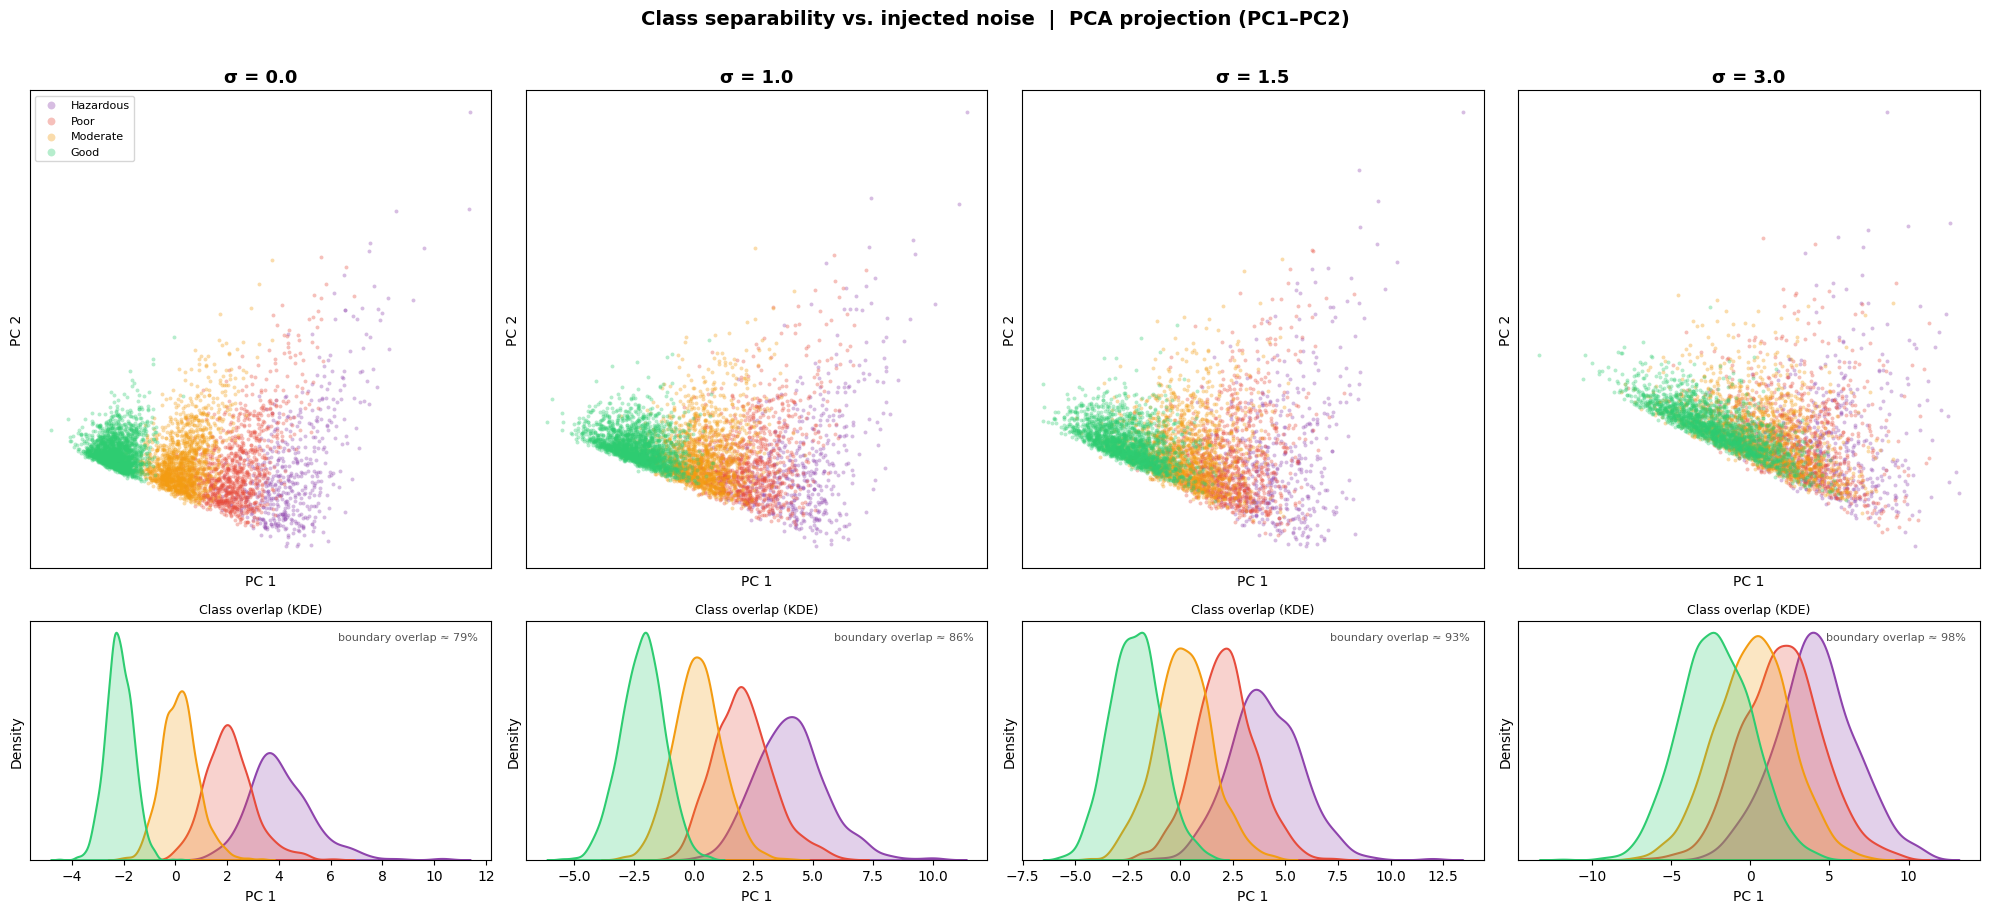

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as SS

CLASS_COLORS = {0: "#8e44ad", 1: "#e74c3c", 2: "#f39c12", 3: "#2ecc71"}

# Reduce to 2D with PCA fitted on clean dataset
pca    = PCA(n_components=2, random_state=RANDOM_STATE)
scaler = SS()
X_scaled_clean = scaler.fit_transform(X_clean)
pca.fit(X_scaled_clean)

fig, axes = plt.subplots(
    2, len(NOISE_LEVELS),
    figsize=(5 * len(NOISE_LEVELS), 9),
    gridspec_kw={"height_ratios": [2, 1]}
)

for col, noise in enumerate(NOISE_LEVELS):
    ax_scatter = axes[0, col]
    ax_kde     = axes[1, col]

    # Generate noisy version
    if noise > 0:
        rng     = np.random.default_rng(RANDOM_STATE + int(noise * 100))
        X_noisy = X_clean + rng.normal(0, noise, X_clean.shape)
    else:
        X_noisy = X_clean.copy()

    # Project to 2D
    X_2d = pca.transform(scaler.transform(X_noisy))

    # PCA Scatter
    for cls in [0, 1, 2, 3]:
        mask = y_clean == cls
        ax_scatter.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=CLASS_COLORS[cls], label=LABEL_MAP[cls],
            alpha=0.35, s=8, linewidths=0
        )

    ax_scatter.set_title(f"σ = {noise}", fontsize=13, fontweight="bold")
    ax_scatter.set_xlabel("PC 1"); ax_scatter.set_ylabel("PC 2")
    if col == 0:
        ax_scatter.legend(markerscale=2, fontsize=8)
    ax_scatter.set_xticks([]); ax_scatter.set_yticks([])

    # Row 2: KDE over PC1
    for cls in [0, 1, 2, 3]:
        mask = y_clean == cls
        sns.kdeplot(
            X_2d[mask, 0],
            ax=ax_kde,
            color=CLASS_COLORS[cls],
            fill=True, alpha=0.25,
            linewidth=1.5,
            label=LABEL_MAP[cls]
        )

    ax_kde.set_xlabel("PC 1"); ax_kde.set_ylabel("Density")
    ax_kde.set_title("Class overlap (KDE)", fontsize=9)
    ax_kde.set_yticks([])

    vals    = [X_2d[y_clean == c, 0] for c in [0, 1, 2, 3]]
    overlap = sum(
        np.mean((vals[i] >= vals[i+1].min()) & (vals[i] <= vals[i+1].max()))
        for i in range(3)
    ) / 3
    ax_kde.annotate(
        f"boundary overlap ≈ {overlap:.0%}",
        xy=(0.97, 0.92), xycoords="axes fraction",
        ha="right", fontsize=8,
        color="#555"
    )

fig.suptitle(
    "Class separability vs. injected noise  |  PCA projection (PC1-PC2)",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

In [ ]:
metrics_cat_0 = {**metrics_cat, "noise": 0.0}
metrics_fh_0  = {**metrics_fh,  "noise": 0.0}
metrics_reg_0 = {**metrics_reg, "noise": 0.0}

all_results = [metrics_cat_0, metrics_fh_0, metrics_reg_0] 

for noise in NOISE_LEVELS_TO_RUN:
    X_train_n, X_test_n, y_train_n, y_test_n = prepare_data_with_noise(X_clean, y_clean, noise)

    # Standard Multiclass
    def objective_cat(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
            "max_depth":         trial.suggest_int("max_depth", 3, 10),
            "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
            "use_label_encoder": False,
            "eval_metric":       "mlogloss",
            "random_state":      RANDOM_STATE,
            "n_jobs":            -1,
        }
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        f1 = cross_val_score(
            XGBClassifier(**params), X_train_n, y_train_n,
            cv=cv, scoring="f1_macro", n_jobs=-1
        ).mean()
        trial.report(f1, step=0)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        return f1

    study_cat = optuna.create_study(
        direction="maximize",
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0),
    )
    study_cat.optimize(objective_cat, n_trials=40, show_progress_bar=True)

    best_params_cat = study_cat.best_params
    best_params_cat.update({"use_label_encoder": False, "eval_metric": "mlogloss",
                            "random_state": RANDOM_STATE, "n_jobs": -1})
    print(f"\n[noise={noise}] Best CV Macro F1 (categorical): {study_cat.best_value:.4f}")

    cat_model = XGBClassifier(**best_params_cat)
    cat_model.fit(X_train_n, y_train_n)
    y_pred_cat = cat_model.predict(X_test_n)

    metrics_cat = evaluate(y_test_n, y_pred_cat, "Standard Multiclass (XGBoost)")
    metrics_cat["noise"] = noise
    all_results.append(metrics_cat)

    # Frank & Hall
    def objective_fh(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
            "max_depth":         trial.suggest_int("max_depth", 3, 10),
            "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "use_label_encoder": False,
            "eval_metric":       "logloss",
            "random_state":      RANDOM_STATE,
            "n_jobs":            -1,
        }
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        qwk_scores = []
        for train_idx, val_idx in cv.split(X_train_n, y_train_n):
            X_tr, X_val = X_train_n[train_idx], X_train_n[val_idx]
            y_tr, y_val = y_train_n[train_idx], y_train_n[val_idx]
            p_gt = {}
            for t in [0, 1, 2]:
                clf = XGBClassifier(**params)
                clf.fit(X_tr, (y_tr > t).astype(int))
                p_gt[t] = clf.predict_proba(X_val)[:, 1]
            p0 = p_gt[0]
            p1 = np.minimum(p_gt[1], p0)
            p2 = np.minimum(p_gt[2], p1)
            proba = np.column_stack([1 - p0, p0 - p1, p1 - p2, p2])
            proba = np.clip(proba, 0, None)
            proba /= proba.sum(axis=1, keepdims=True)
            y_pred_fold = np.argmax(proba, axis=1)
            qwk_scores.append(cohen_kappa_score(y_val, y_pred_fold, weights="quadratic"))
        qwk = np.mean(qwk_scores)
        trial.report(qwk, step=0)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        return qwk

    study_fh = optuna.create_study(
        direction="maximize",
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0),
    )
    study_fh.optimize(objective_fh, n_trials=40, show_progress_bar=True)

    best_params_fh = study_fh.best_params
    best_params_fh.update({"use_label_encoder": False, "eval_metric": "logloss",
                            "random_state": RANDOM_STATE, "n_jobs": -1})
    print(f"\n[noise={noise}] Best CV QWK (Frank & Hall): {study_fh.best_value:.4f}")

    bin_models = {}
    for t in [0, 1, 2]:
        clf = XGBClassifier(**best_params_fh)
        clf.fit(X_train_n, (y_train_n > t).astype(int))
        bin_models[t] = clf

    p_gt = {t: bin_models[t].predict_proba(X_test_n)[:, 1] for t in [0, 1, 2]}
    p0 = p_gt[0]
    p1 = np.minimum(p_gt[1], p0)
    p2 = np.minimum(p_gt[2], p1)
    proba_ord = np.column_stack([1 - p0, p0 - p1, p1 - p2, p2])
    proba_ord = np.clip(proba_ord, 0, None)
    proba_ord /= proba_ord.sum(axis=1, keepdims=True)
    y_pred_fh = np.argmax(proba_ord, axis=1)

    metrics_fh = evaluate(y_test_n, y_pred_fh, "Ordinal — Frank & Hall")
    metrics_fh["noise"] = noise
    all_results.append(metrics_fh)

    # Regressor Ensemble
    def objective_reg(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
            "max_depth":         trial.suggest_int("max_depth", 3, 10),
            "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "random_state":      RANDOM_STATE,
            "n_jobs":            -1,
        }
        t1 = trial.suggest_float("t1", 0.3, 1.2)
        t2 = trial.suggest_float("t2", 1.2, 2.2)
        t3 = trial.suggest_float("t3", 2.2, 3.0)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        qwk_scores = []
        for train_idx, val_idx in cv.split(X_train_n, y_train_n):
            X_tr, X_val = X_train_n[train_idx], X_train_n[val_idx]
            y_tr, y_val = y_train_n[train_idx], y_train_n[val_idx]
            reg = XGBRegressor(**params)
            reg.fit(X_tr, y_tr)
            preds_raw = reg.predict(X_val)
            preds     = np.digitize(preds_raw, bins=[t1, t2, t3])
            qwk_scores.append(cohen_kappa_score(y_val, preds, weights="quadratic"))
        qwk = np.mean(qwk_scores)
        trial.report(qwk, step=0)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        return qwk

    study_reg = optuna.create_study(
        direction="maximize",
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0),
    )
    study_reg.optimize(objective_reg, n_trials=50, show_progress_bar=True)

    best = study_reg.best_params
    print(f"\n[noise={noise}] Best CV QWK (Regressor): {study_reg.best_value:.4f}")
    print(f"Optimal thresholds — t1={best['t1']:.3f}, t2={best['t2']:.3f}, t3={best['t3']:.3f}")

    reg_params = {k: v for k, v in best.items() if k not in ["t1", "t2", "t3"]}
    reg_params.update({"random_state": RANDOM_STATE, "n_jobs": -1})

    reg_model  = XGBRegressor(**reg_params)
    reg_model.fit(X_train_n, y_train_n)
    preds_raw  = reg_model.predict(X_test_n)
    y_pred_reg = np.digitize(preds_raw, bins=[best["t1"], best["t2"], best["t3"]])

    metrics_reg = evaluate(y_test_n, y_pred_reg, "Ordinal — Regressor Ensemble")
    metrics_reg["noise"] = noise
    all_results.append(metrics_reg)

results_noise_df = pd.DataFrame(all_results)
results_noise_df.head()

  0%|          | 0/40 [00:00<?, ?it/s]


[noise=1.0] Best CV Macro F1 (categorical): 0.8635


  0%|          | 0/40 [00:00<?, ?it/s]


[noise=1.0] Best CV QWK (Frank & Hall): 0.9481


  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/40 [00:00<?, ?it/s]


[noise=3.0] Best CV QWK (Frank & Hall): 0.9192


  0%|          | 0/50 [00:00<?, ?it/s]


[noise=3.0] Best CV QWK (Regressor): 0.9161
Optimal thresholds — t1=0.709, t2=1.531, t3=2.451


,Model,Accuracy,Macro F1,MCC,MAE (class steps),Adjacent Accuracy,Quadratic Weighted κ,Linear Weighted κ,Kendall's τ,Spearman's ρ,Severe Error Rate (≥2),Adjacent Error Rate,noise
0,Standard Multiclass (XGBoost),0.944,0.9212,0.9200,0.056,1.0,0.9711,0.9473,0.9669,0.9820,0.0,0.056,0.0
1,Ordinal — Frank & Hall,0.949,0.9263,0.9271,0.051,1.0,0.9737,0.9520,0.9706,0.9843,0.0,0.051,0.0
2,Ordinal — Regressor Ensemble,0.945,0.9222,0.9215,0.055,1.0,0.9724,0.9489,0.9678,0.9827,0.0,0.055,0.0
3,Standard Multiclass (XGBoost),0.913,0.8804,0.8753,0.087,1.0,0.9552,0.9181,0.9466,0.9688,0.0,0.087,1.0
4,Ordinal — Frank & Hall,0.910,0.8757,0.8711,0.090,1.0,0.9539,0.9155,0.9453,0.9685,0.0,0.090,1.0


In [ ]:
def highlight_best(s):
    lower_is_better = {"MAE (class steps)", "Severe Error Rate (≥2)", "Adjacent Error Rate"}
    if s.name in lower_is_better:
        best = s == s.min()
    else:
        best = s == s.max()
    return ["font-weight: bold; color: green" if v else "" for v in best]

for noise in NOISE_LEVELS:
    print(f"\n{'='*55}\n  noise = {noise}\n{'='*55}")
    df_noise = (
        results_noise_df[results_noise_df["noise"] == noise]
        .set_index("Model")
        .drop(columns=["noise"])
    )
    display(df_noise.T.style.apply(highlight_best, axis=1))


  noise = 0.0


Model,Standard Multiclass (XGBoost),Ordinal — Frank & Hall,Ordinal — Regressor Ensemble
Accuracy,0.944000,0.949000,0.945000
Macro F1,0.921200,0.926300,0.922200
MCC,0.920000,0.927100,0.921500
MAE (class steps),0.056000,0.051000,0.055000
Adjacent Accuracy,1.000000,1.000000,1.000000
Quadratic Weighted κ,0.971100,0.973700,0.972400
Linear Weighted κ,0.947300,0.952000,0.948900
Kendall's τ,0.966900,0.970600,0.967800
Spearman's ρ,0.982000,0.984300,0.982700
Severe Error Rate (≥2),0.000000,0.000000,0.000000



  noise = 1.0


Model,Standard Multiclass (XGBoost),Ordinal — Frank & Hall,Ordinal — Regressor Ensemble
Accuracy,0.913000,0.910000,0.908000
Macro F1,0.880400,0.875700,0.872600
MCC,0.875300,0.871100,0.868100
MAE (class steps),0.087000,0.090000,0.092000
Adjacent Accuracy,1.000000,1.000000,1.000000
Quadratic Weighted κ,0.955200,0.953900,0.953400
Linear Weighted κ,0.918100,0.915500,0.914100
Kendall's τ,0.946600,0.945300,0.943500
Spearman's ρ,0.968800,0.968500,0.966700
Severe Error Rate (≥2),0.000000,0.000000,0.000000



  noise = 1.5


Model,Standard Multiclass (XGBoost),Ordinal — Frank & Hall,Ordinal — Regressor Ensemble
Accuracy,0.888000,0.899000,0.887000
Macro F1,0.855200,0.869100,0.860800
MCC,0.839500,0.855300,0.838800
MAE (class steps),0.113000,0.101000,0.113000
Adjacent Accuracy,0.999000,1.000000,1.000000
Quadratic Weighted κ,0.941600,0.949000,0.943600
Linear Weighted κ,0.894400,0.905800,0.895600
Kendall's τ,0.925600,0.934100,0.924500
Spearman's ρ,0.953400,0.959000,0.952300
Severe Error Rate (≥2),0.001000,0.000000,0.000000



  noise = 3.0


Model,Standard Multiclass (XGBoost),Ordinal — Frank & Hall,Ordinal — Regressor Ensemble
Accuracy,0.849000,0.851000,0.830000
Macro F1,0.817000,0.824100,0.799100
MCC,0.783000,0.786200,0.757700
MAE (class steps),0.154000,0.152000,0.173000
Adjacent Accuracy,0.997000,0.997000,0.997000
Quadratic Weighted κ,0.916800,0.919300,0.913500
Linear Weighted κ,0.854200,0.857500,0.842200
Kendall's τ,0.891400,0.891100,0.879800
Spearman's ρ,0.926200,0.926000,0.918500
Severe Error Rate (≥2),0.003000,0.003000,0.003000


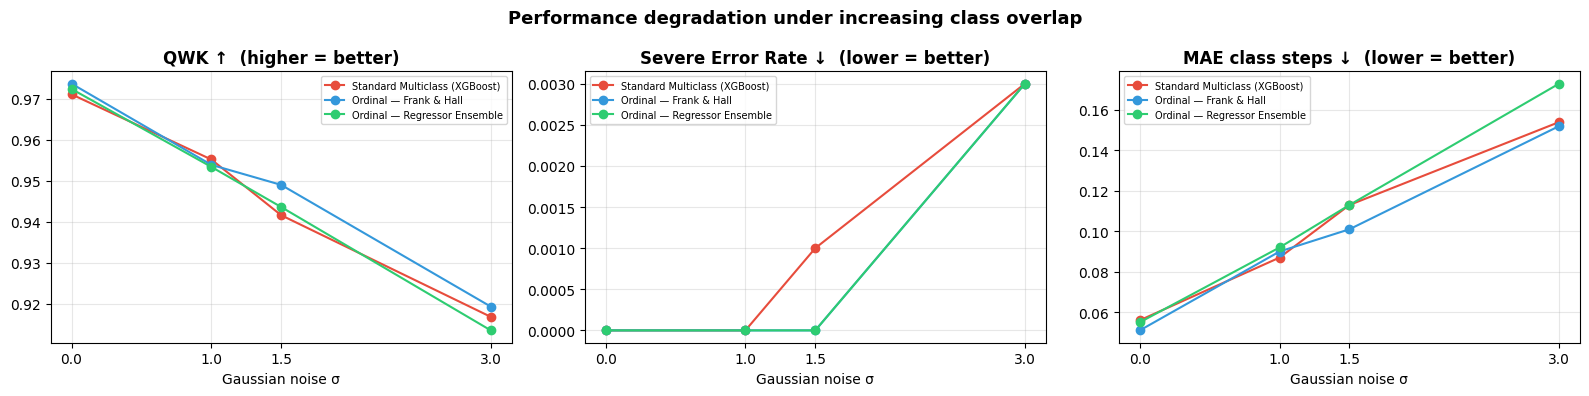

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = {
    "Standard Multiclass (XGBoost)": "#e74c3c",
    "Ordinal — Frank & Hall":         "#3498db",
    "Ordinal — Regressor Ensemble":   "#2ecc71",
}

for model, c in colors.items():
    df_m = results_noise_df[results_noise_df["Model"] == model]

    axes[0].plot(df_m["noise"], df_m["Quadratic Weighted κ"],
                marker="o", label=model, color=c)
    axes[1].plot(df_m["noise"], df_m["Severe Error Rate (≥2)"],
                marker="o", label=model, color=c)
    axes[2].plot(df_m["noise"], df_m["MAE (class steps)"],
                marker="o", label=model, color=c)

titles = [
    "QWK ↑  (higher = better)",
    "Severe Error Rate ↓  (lower = better)",
    "MAE class steps ↓  (lower = better)",
]
for ax, title in zip(axes, titles):
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Gaussian noise σ")
    ax.set_xticks(NOISE_LEVELS)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle(
    "Performance degradation under increasing class overlap",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

## Robustness Analysis — Conclusions

As we can see in the results, as noise increases all three models perform worse, dropping from 94-95% accuracy at σ=0 down to 83-85% at σ=3.0. That part is expected and nearly the same across all the models and different noise levels. The more interesting differences show up in the ordinal metrics.

**At σ=1.0** all three models still produce zero severe errors, and performance is very close to the noise-less models QWK around 0.95 with Standard Multiclass slightly ahead (0.9552 vs 0.9539 and 0.9534). No method is clearly better at this noise level, as it is the most close one with the original data.

**At σ=1.5** Frank & Hall starts to be the best at every metric, but not really ahead of the other models. The ordinal models are the only ones with zero severe errors, and F&H leads on every ordinal-based metric. This seems to be the noise level where encoding ordinality starts to affect the results, but without a clear winner.

**At σ=3.0** as we expected, all the metrics for the 3 models are worse, but still quite good. All three models produce the same severe error rate, so the ordinal advantage disappears under heavy noise. Frank & Hall still leads slightly on QWK and MAE, but the gaps are still small. The Regressor Ensemble is the weakest model of the three at this high noise level.

## Conclusion
To summarise, on clean or little noisy data the three models are essentially almost the same, as they produce really high, but still similar results. At moderate noise Frank & Hall is the most conservative, it avoids severe errors longer than the standard classifier and the regressor. At very high noise all methods converge and the ordinal advantage goes away. The Regressor Ensemble, despite being, in theory, the most flexible, does not outperform the other two under noise on this dataset. 
We also expected the results to be worse as we increased the noise level, but it hasn't been a clear winner between the three models. As a last conclusion, we can say that both three models have learnt the mathematical formula behind the classification of the air quality level, so there is not a clear outcome of which method is a better approach to this problem as well as there isn't a clear finding on if taking into account the ordinality matters.

## Future Work

For the future we can analyse these following sections in order to go deeper on this exact topic:

- **Using real-world data**: validate on a real air quality dataset where class overlap exists naturally rather than being artificially injected, and also having real examples of outliers, missing values and more 'real features'.
- **Alternative ordinal methods**: explore frameworks with stronger theoretical guarantees such as CORAL or proportional odds models as additional baselines.
- **Cost-sensitive evaluation**: explicitly penalise severe errors during training via a custom loss, rather than only measuring them after all the proccess.
- **Threshold refinement**: investigate per-class or per-region threshold tuning for the Regressor Ensemble, since the optimal difference between adjacent classes may not be uniform.
- **Realistic noise**: replace isotropic Gaussian noise with feature-specific perturbations that reflect actual sensor degradation or miscalculation patterns.